In [9]:
import os
from langgraph.graph import StateGraph, START, END, add_messages
from langgraph.checkpoint.memory import InMemorySaver

from dotenv import load_dotenv
from langchain_groq import ChatGroq
from langchain_core.messages import HumanMessage, SystemMessage, BaseMessage
from typing import TypedDict, Annotated
from langchain.messages import RemoveMessage # it is use to delete messages from state permanantly
from langchain_core.messages import HumanMessage
from langgraph.checkpoint.memory import InMemorySaver

In [10]:
load_dotenv()

llm= ChatGroq(
    model="llama-3.3-70b-versatile",
    api_key=os.getenv("GROQ_API_KEY")
)

class MessagesState(TypedDict):
    messages: Annotated[list[BaseMessage], add_messages]

In [11]:
def chat_model(state:MessagesState):
    messages= [SystemMessage(content="You are a QUESTION-ANSWER assistent.And answer only if you know other-wise explicitly tell you don't know!"), *state['messages']]

    ai_response= llm.invoke(messages)
    return {"messages":[ai_response]}

def delete_old_messages(state:MessagesState):
    msgs= state['messages']

    print(f"\nBefore cleanup, number of messages: {len(state['messages'])}\n")
    if len(msgs)>10:
        to_remove= msgs[:6]

        return {"messages":[RemoveMessage(id=m.id) for m in to_remove]}

    return {}
    

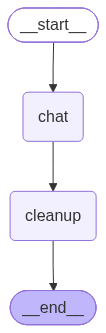

In [12]:
builder= StateGraph(MessagesState)

builder.add_node('chat', chat_model)
builder.add_node('cleanup', delete_old_messages)

builder.add_edge(START, 'chat')
builder.add_edge('chat', 'cleanup')
builder.add_edge('cleanup', END)

checkpointer= InMemorySaver()

graph= builder.compile(checkpointer)

graph

In [14]:
# Run multiple turns 

CONFIG= {'configurable':{'thread_id':"thread-1"}}

output1 = graph.invoke({"messages":[HumanMessage(content="Hi, I'am aditya!")]}, config=CONFIG)
output2 = graph.invoke({"messages":[HumanMessage(content="Tell me about langgraph")]}, config=CONFIG)
output3 = graph.invoke({"messages":[HumanMessage(content="Now explain checkpointers")]}, config=CONFIG)
output4 = graph.invoke({"messages":[HumanMessage(content="What is langchain")]}, config=CONFIG)
output5 = graph.invoke({"messages":[HumanMessage(content="what is Quantum Mechanics")]}, config=CONFIG)
output6 = graph.invoke({"messages":[HumanMessage(content="what is Gen Ai")]}, config=CONFIG)
output7 = graph.invoke({"messages":[HumanMessage(content="what is my name")]}, config=CONFIG)


Before cleanup, number of messages: 2


Before cleanup, number of messages: 4


Before cleanup, number of messages: 6


Before cleanup, number of messages: 8


Before cleanup, number of messages: 10


Before cleanup, number of messages: 12


Before cleanup, number of messages: 8



In [ ]:
print(output1['messages'][-1].content)
print(output2['messages'][-1].content)
print(output3['messages'][-1].content)
print(output4['messages'][-1].content)
print(output5['messages'][-1].content)
print(output6['messages'][-1].content)
print(output7['messages'][-1].content) # see last one

Hello Aditya, how can I assist you today?
LangGraph is an open-source, AI-powered platform that allows developers to build, train, and deploy large language models. It's designed to be highly customizable and scalable, enabling users to create models tailored to their specific needs.

LangGraph provides a range of features, including:

1. **Model training**: LangGraph allows users to train large language models from scratch or fine-tune pre-trained models on their own datasets.
2. **Model deployment**: Once trained, models can be deployed as APIs, enabling integration with various applications and services.
3. **Customization**: LangGraph provides a range of customization options, including support for different architectures, hyperparameters, and training objectives.
4. **Scalability**: LangGraph is designed to scale horizontally, allowing users to train and deploy large models on distributed computing infrastructure.

LangGraph is particularly useful for applications such as:

1. **N

In [27]:
# now if we verify how many messages are present in our state
len(graph.get_state(config=CONFIG).values['messages'])

8